# D1Q3 Generic Moments - Wheight Variation

In [1]:
from __future__ import division
from sympy import *
import numpy as np
from sympy import S, collect, expand, factor, Wild
from sympy import fraction, Rational, Symbol
from sympy import symbols, sqrt, Rational
import sympy as sp
from IPython.display import display, Math, Latex
#-------------------------------------------------Símbolos----------------------------------------------
omega, rho, w, theta, d = symbols('omega, \\rho^{*}, w, \\theta, \\partial')
ux, uy, tauxx, tauxy, tauyy = symbols('u^{*}_{x} u^{*}_{y} \\tau^{*}_{xx} \\tau^{*}_{xy} \\tau^{*}_{yy}')
wi, cx, cy, cs = symbols('w_{i} c_{x} c_{y} c_{s}')
w0s, w1s, w2s, w3s = symbols('w_{0} w_{1} w_{2} w_{3}')
#--------------------------------------Simbolos--Buckley--Model--------------------------------------------
b, sxx, s, lan, La, Pi, Pi4 = symbols('B_{\\alpha} s_{xx} s_{k} \\lambda \\Lambda_{\\alpha\\beta} \\Pi_{\\alpha\\beta\\gamma} \\Pi_{\\alpha\\beta\\gamma\\delta}')
#-------------------------------------------------Funções----------------------------------------------
feq = Function('feq')(wi, cx, cy)
#-------------------------------------------------Variáveis-D2V17----------------------------------------------
# cs = 1/sp.sqrt(2)
cs = 1/sp.sqrt(Rational(4,3))
w1=(cs**2)/2;
w0=1-2*w1;
# w2=Rational(1,36);
ass= 1/cs
#-------------------------------------------------Variáveis-D1V5----------------------------------------------
wi=np.array([w0,w1,w1])
wis=np.array([w0s,w1s,w1s])
cx=np.array([0,1,-1])
#-------------------------------------------------Calc.Func------------------------------------------------
feq=wi*(s 
        + cx*b*ass**2 
          +(ass**4)*Rational(1,2)*(La-s*cs**2)*(cx*cx-cs**2)*1
         # +(ass**6)*Rational(1,6)*(Pi-3*b*cs**2)*(cx*cx-3*cs**2)*cx/1
       )

In [4]:
display(simplify(sum(feq)))
display(simplify(sum(feq*cx)))
display(simplify(sum(feq*cx*cx)))
display(simplify(sum(feq*cx*cx*cx)))
# display(collect(expand(simplify(sum(feq*cx*cx*cx*cx))),Pi4))
display(Math(r"c_{s}^{2}="+sp.latex(cs) + r",\quad w_{0}="+ sp.latex(w0) + r",\quad w_{1}="+ sp.latex(w1) ))
display(simplify(sum(feq*cx*cx)).coeff(La))

s_{k}

B_{\alpha}

\Lambda_{\alpha\beta}/6 + 5*s_{k}/8

B_{\alpha}

<IPython.core.display.Math object>

1/6

In [8]:
import sympy as sp
from sympy import Rational, simplify, symbols

s, b, La, Pi = symbols('s b \\Lambda_{\\alpha\\beta} \\Pi_{\\alpha\\beta\\gamma}')

cs_vals   = sp.Matrix([Rational(n, 1000) for n in range(1, 1001)])
coef_vals = sp.Matrix([Rational(0)] * 1001)
w1_vals   = cs_vals.applyfunc(lambda c: c**2 / 2)
w0_vals   = w1_vals.applyfunc(lambda w: 1 - 2*w)
ass_vals  = cs_vals.applyfunc(lambda c: 1/c)

cx = [0, 1, -1]   # plain Python list, NOT np.array, NOT sp.Matrix

for i in range(len(cs_vals)):
    w_i  = [w0_vals[i], w1_vals[i], w1_vals[i]]
    cs_i = cs_vals[i]
    as_i = ass_vals[i]

    # build feq[k] for each direction k = 0,1,2
    feq = []
    for k in range(3):
        cxk = cx[k]
        expr = (
            s
            + cxk * b * as_i**2
            + (as_i**4) * Rational(1, 2)
              * (La - s*cs_i**2)
              * (cxk**2 - cs_i**2)
        )
        feq.append(w_i[k] * expr)

    # contraction: sum_k feq[k] * cx[k]^2
    total = sum(feq[k] * cx[k]**2 for k in range(3))
    coef_vals[i] = simplify(total).coeff(La)

In [9]:
coef_vals[:10]

[999999/2,
 249999/2,
 999991/18,
 62499/2,
 39999/2,
 249991/18,
 999951/98,
 7812,
 999919/162,
 9999/2]

In [10]:
coef_correc = coef_vals.applyfunc(lambda cf: 1/cf)
coef_correc[:10]

[2/999999,
 2/249999,
 18/999991,
 2/62499,
 2/39999,
 18/249991,
 98/999951,
 1/7812,
 162/999919,
 2/9999]

In [12]:
coef_correc = coef_vals.applyfunc(lambda cf: 1/cf)
coef2_vals = sp.Matrix([Rational(0)] * 1001)
for i in range(len(cs_vals)):
    w_i  = [w0_vals[i], w1_vals[i], w1_vals[i]]
    cs_i = cs_vals[i]
    as_i = ass_vals[i]
    correc_i = coef_correc[i]

    # build feq[k] for each direction k = 0,1,2
    feq = []
    for k in range(3):
        cxk = cx[k]
        expr = (s + cxk * b * as_i**2
            + (as_i**4) * Rational(1, 2)
              * (La - s * cs_i**2) * (cxk**2 - cs_i**2) * correc_i)
        feq.append(w_i[k] * expr)

    # contraction: sum_k feq[k] * cx[k]^2
    total = sum(feq[k] * cx[k]**2 for k in range(3))
    coef2_vals[i] = simplify(total).coeff(La)

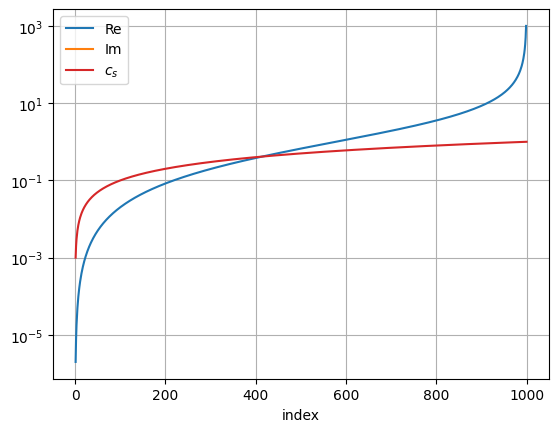

In [29]:
import numpy as np
import matplotlib.pyplot as plt

y_real = np.array([float(v.as_real_imag()[0]) for v in coef_correc])
y_imag = np.array([float(v.as_real_imag()[1]) for v in coef_correc])
y_cs   = np.array([float(c) for c in cs_vals])

x = np.arange(1, len(coef_correc) + 1)
x2 = np.arange(1, len(coef_correc) )

plt.figure()
plt.semilogy(x, y_real, label="Re")
plt.semilogy(x, y_imag, label="Im")
plt.plot(x2, y_cs, color="tab:red", label=r"$c_s$")
plt.xlabel("index")
plt.legend()
plt.grid(True)
plt.show()

In [3]:
display(simplify(sum(feq)))
display(simplify(sum(feq*cx)))
display(simplify(sum(feq*cx*cx)))
display(simplify(sum(feq*cx*cx*cx)))


s_{k}

B_{\alpha}

\Lambda_{\alpha\beta}/6 + 5*s_{k}/8

B_{\alpha}

In [61]:
display(simplify(sum(feq)))
display(simplify(sum(feq*cx)))
display(collect(expand(simplify(sum(feq*(cx*cx-cs**2)))),{s,La}))
display(collect(expand(simplify(sum(feq*(cx*cx*cx-3*cx*cs**2)))),Pi))

s_{k}

B_{\alpha}

0

-2*B_{\alpha}

# Continuo $\mathcal{H}^{0}$

In [4]:
from __future__ import division
from sympy import *
import numpy as np
from sympy import S, collect, expand, factor, Wild
from sympy import fraction, Rational, Symbol
from sympy import symbols, sqrt, Rational
import sympy as sp
from IPython.display import display, Math, Latex
xi = symbols('\\xi')
r = symbols('r')
fw0=1/sp.sqrt(sp.pi*2)*sp.exp(-xi**2/(r*2))
intfw0 = sp.integrate(fw0, (xi, -sp.oo, sp.oo))
display(fw0)
display(intfw0)

sqrt(2)*exp(-\xi**2/(2*r))/(2*sqrt(pi))

Piecewise((r/sqrt(polar_lift(r)), Abs(arg(r)) <= pi/2), (Integral(sqrt(2)*exp(-\xi**2/(2*r))/(2*sqrt(pi)), (\xi, -oo, oo)), True))

In [7]:
import sympy as sp
from IPython.display import display

xi = sp.symbols(r'\xi', real=True)
r  = sp.symbols('r', positive=True, real=True)

fw0 = 1/sp.sqrt(sp.pi*2) * sp.exp(-xi**2/(r*2))

intfw0 = sp.integrate(fw0, (xi, -sp.oo, sp.oo))

display(fw0)
display(sp.simplify(intfw0))

sqrt(2)*exp(-\xi**2/(2*r))/(2*sqrt(pi))

sqrt(r)

## D2Q9 Projection

In [39]:
#--------------------------------------Simbolos--Buckley--Model--------------------------------------------
bx, by, Laxx, Laxy, Layy , Pxxy, Pxyy, Gxxyy = symbols('B_{x}, B_{y}, \\Lambda_{xx}, \\Lambda_{xy}, \\Lambda_{yy}, \\Pi_{xxy}, \\Pi_{xyy}, \\Gamma_{xxyy}')
#-------------------------------------------------Variáveis----------------------------------------------
w09=w0*w0; w19=w0*w1; w29=w1*w1;
wi9=np.array([w09,w19,w19,w19,w19,w29,w29,w29,w29])
cx9=np.array([0,1,0,-1,0,1,-1,-1,1])
cy9=np.array([0,0,1,0,-1,1,1,-1,-1])
#-------------------------------------------------Funções----------------------------------------------
feq9 = Function('feq')(wi9, cx9, cy9)
#-------------------------------------------------Calc.Func------------------------------------------------
feq9=wi9*(s + ass**2*(cx9*bx + cy9*by)  
          
             +(ass**4)*(Laxx-s*cs**2)*(cx9*cx9 - cs**2) /8
             +2*(ass**4)*Laxy*(cx9*cy9)/2
             +(ass**4)*(Layy-s*cs**2)*(cy9*cy9 - cs**2)/8

             +3*(ass**6)*(Pxxy - by*cs**2)*(cx9*cx9*cy9 - cy9*cs**2)/6/4
             +3*(ass**6)*(Pxyy - bx*cs**2)*(cx9*cy9*cy9 - cx9*cs**2)/6/4

              +6*(ass**8)*(Gxxyy -(Laxx+Layy)*cs**2 + s*cs**4)*(cx9*cx9*cy9*cy9-(cx9*cx9+cy9*cy9)*cs**2 + cs**4)/24/4/4
         )

In [40]:
display(simplify(sum(feq9)))
display(simplify(sum(feq9*cx9)))
display(simplify(sum(feq9*cy9)))
display(expand(simplify(sum(feq9*cx9*cx9))))
display(expand(simplify(sum(feq9*cx9*cy9))))
display(expand(simplify(sum(feq9*cy9*cy9))))
display(expand(simplify(sum(feq9*cx9*cx9*cy9))))
display(expand(simplify(sum(feq9*cx9*cy9*cy9))))
display(expand(simplify(sum(feq9*cx9*cx9*cy9*cy9))))


s_{k}

B_{x}

B_{y}

\Lambda_{xx}

\Lambda_{xy}

\Lambda_{yy}

\Pi_{xxy}

\Pi_{xyy}

\Gamma_{xxyy}

# Continuo $\mathcal{H}^{0}$

In [34]:
fw0=1/sp.sqrt(sp.pi*2)*sp.exp(-xi**2/2)
intfw0 = sp.integrate(fw0, (xi, -sp.oo, sp.oo))
display(fw0)
display(intfw0)

sqrt(2)*exp(-\xi**2/2)/(2*sqrt(pi))

1

In [35]:
fw0=1/sp.sqrt(sp.pi*2*theta)*sp.exp(-xi**2/(2*theta))
intfw0 = sp.integrate(fw0, (xi, -sp.oo, sp.oo))
display(fw0)
display(intfw0)

sqrt(2)*exp(-\xi**2/(2*\theta))/(2*sqrt(pi)*sqrt(\theta))

Piecewise((sqrt(\theta)/sqrt(polar_lift(\theta)), Abs(arg(\theta)) <= pi/2), (Integral(sqrt(2)*exp(-\xi**2/(2*\theta))/(2*sqrt(pi)*sqrt(\theta)), (\xi, -oo, oo)), True))

# Continuo $\mathcal{H}^{1}_{x}$

In [36]:
fw1=1/sp.sqrt(sp.pi*2)*sp.exp(-xi**2/2)*xi*xi
intfw1 = sp.integrate(fw1, (xi, -sp.oo, sp.oo))
display(fw1)
display(intfw1)

sqrt(2)*\xi**2*exp(-\xi**2/2)/(2*sqrt(pi))

1

In [37]:
fw1=1/sp.sqrt(sp.pi*2*theta)*sp.exp(-xi**2/(2*theta))*xi*xi
intfw1 = sp.integrate(fw1, (xi, -sp.oo, sp.oo))
display(fw1)
display(intfw1)

sqrt(2)*\xi**2*exp(-\xi**2/(2*\theta))/(2*sqrt(pi)*sqrt(\theta))

Piecewise((sqrt(\theta)*sqrt(polar_lift(\theta)), Abs(arg(\theta)) < pi/2), (Integral(sqrt(2)*\xi**2*exp(-\xi**2/(2*\theta))/(2*sqrt(pi)*sqrt(\theta)), (\xi, -oo, oo)), True))

# Continuo $\mathcal{H}^{2}_{xx}$

In [38]:
fw2=1/sp.sqrt(sp.pi*2)*sp.exp(-xi**2/2)*(xi*xi-1)*(xi*xi-1)
intfw2 = sp.integrate(fw2, (xi, -sp.oo, sp.oo))
display(fw2)
display(intfw2)

sqrt(2)*(\xi**2 - 1)**2*exp(-\xi**2/2)/(2*sqrt(pi))

2

In [39]:
fw2=1/sp.sqrt(sp.pi*2*theta)*sp.exp(-xi**2/(2*theta))*(xi*xi-1)*(xi*xi-1)
intfw2 = sp.integrate(fw2, (xi, -sp.oo, sp.oo))
display(fw2)
display(intfw2)

sqrt(2)*(\xi**2 - 1)**2*exp(-\xi**2/(2*\theta))/(2*sqrt(pi)*sqrt(\theta))

Piecewise((3*sqrt(\theta)*polar_lift(\theta)**(3/2) - 2*sqrt(\theta)*sqrt(polar_lift(\theta)) + sqrt(\theta)/sqrt(polar_lift(\theta)), (Abs(arg(\theta)) <= pi/2) & (Abs(arg(\theta)) < pi/2)), (Integral(sqrt(2)*(\xi**2 - 1)**2*exp(-\xi**2/(2*\theta))/(2*sqrt(pi)*sqrt(\theta)), (\xi, -oo, oo)), True))

# Continuo $\mathcal{H}^{3}_{xxx}$

In [40]:
fw3=1/sp.sqrt(sp.pi*2)*sp.exp(-xi**2/2)*(xi*xi*xi-3*xi)*(xi*xi*xi-3*xi)
intfw3 = sp.integrate(fw3, (xi, -sp.oo, sp.oo))
display(fw3)
display(intfw3)

sqrt(2)*(\xi**3 - 3*\xi)**2*exp(-\xi**2/2)/(2*sqrt(pi))

6

# Continuo $\mathcal{H}^{4}_{xxxx}$

In [41]:
fw4=1/sp.sqrt(sp.pi*2)*sp.exp(-xi**2/2)*(xi*xi*xi*xi-6*xi*xi+3)*(xi*xi*xi*xi-6*xi*xi+3)
intfw4 = sp.integrate(fw4, (xi, -sp.oo, sp.oo))
display(fw4)
display(intfw4)

sqrt(2)*(\xi**4 - 6*\xi**2 + 3)**2*exp(-\xi**2/2)/(2*sqrt(pi))

24

# Lattice D1Q2 

In [42]:
A0=2*w1-1
B0=2*w1*hs*hs-1
sols = solve([A0, B0], [w1,hs], dict=True)

In [43]:
MatAdd(sols[0][w1],sols[0][hs])

-1 + 1/2

# Lattice D3Q7

In [44]:
A0=w0+6*w1-1
B0=6*w1*hs*hs-1
C0=w0+6*w1*(hs*hs-1)**2-2
sols = solve([A0, B0,C0], [w0,w1,hs], dict=True)
MatAdd(sols[0][w0],sols[0][w1],sols[0][hs])

-sqrt(3) + 1/18 + 2/3

# Lattice D1Q3

In [45]:
A0=w0+2*w1-1
B0=2*w1*hs*hs-1
C0=w0+2*w1*(hs*hs-1)**2-2
sols = solve([A0, B0,C0], [w0,w1,hs], dict=True)
MatAdd(sols[0][w0],sols[0][w1],sols[0][hs])

-sqrt(3) + 1/6 + 2/3

In [46]:
wi=np.array([sols[0][w0],sols[0][w1],sols[0][w1]])
hs2=sols[0][hs]**2
feq=wi*(s + cx3*b*hs2 + (hs2**2)*Rational(1,2)*(La-s/hs2)*(cx3*cx3-1/hs2) )
# feq=wi*(s + cx3*b*hs2 )
display(simplify(sum(feq)))
display(simplify(sum(feq*cx3)))
display(collect(expand(simplify(sum(feq*(cx3*cx3*Rational(1,1)-1/hs2 - Rational(0,3) )))),{s,La}))

s_{k}

B_{\alpha}

\Lambda_{\alpha\beta} - s_{k}/3

In [47]:
A0=w0+2*w1-1
B0=2*w1*hs**2-1
C0=w0 + 2*w1*(hs*hs-1)**2 - 2
sols = solve([A0, B0,C0], [w0,w1,hs], dict=True)
MatAdd(sols[0][w0],sols[0][w1],sols[0][hs])


-sqrt(3) + 1/6 + 2/3

# Lattice D1Q3-2

In [48]:
hs=sp.sqrt(Rational(3,2))
hs2=hs**2
A0=w0+2*w1-1
B0=2*w1*hs*hs-1
C0=w0+2*w1*(hs*hs-1)**2-2
# sols = solve([A0, B0,C0], [w0,w1,hs], dict=True)
sols = solve([A0, B0], [w0,w1], dict=True)
MatAdd(sols[0][w0],sols[0][w1])

1/3 + 1/3

In [49]:
wi=np.array([sols[0][w0],sols[0][w1],sols[0][w1]])
# feq=wi*(s + cx3*b*hs2 + (hs2**2)*Rational(1,2)*(La-s/hs2)*(cx3*cx3-1/hs2) + (hs2**3)*Rational(1,6)*(Pi-3*b/hs2)*(cx3*cx3-3/hs2)*cx3 )
feq=wi*(s + cx3*b*hs2 + (hs2**2)*Rational(1,2)*(La-s/hs2)*(cx3*cx3-1/hs2) )
# feq=wi*(s + cx3*b*hs2 )
display(simplify(sum(feq)))
display(simplify(sum(feq*cx3)))
# display(collect(expand(simplify(sum(feq*cx3*cx3))),{s,La}))
display(collect(expand(simplify(sum(feq*(cx3*cx3*Rational(4,1)-1/hs2 - Rational(4,3) )))),{s,La}))
display( simplify(sum(feq*(cx3*cx3*Rational(1,1) - Rational(0,3) ))))
display(collect(expand(simplify(sum(feq*(cx3*cx3-3/hs2+Rational(1,1))*cx3))),Pi))

s_{k}

B_{\alpha}

\Lambda_{\alpha\beta}

\Lambda_{\alpha\beta}/4 + s_{k}/2

0

In [54]:
hs=sp.sqrt(Rational(2,1))
hs2=hs**2
A0=w0+2*w1-1
B0=2*w1*hs*hs-1
C0=w0+2*w1*(hs*hs-1)**2-2
# sols = solve([A0, B0,C0], [w0,w1,hs], dict=True)
sols = solve([A0, B0], [w0,w1], dict=True)
MatAdd(sols[0][w0],sols[0][w1])

1/4 + 1/2

In [55]:
wi=np.array([sols[0][w0],sols[0][w1],sols[0][w1]])
feq=wi*(s + cx3*b*hs2 + (hs2**2)*Rational(1,2)*(La-s/hs2)*(cx3*cx3-1/hs2) + (hs2**3)*Rational(1,6)*(Pi-3*b/hs2)*(cx3*cx3-3/hs2)*cx3 )
# feq=wi*(s + cx3*b*hs2 + (hs2**2)*Rational(1,2)*(La-s/hs2)*(cx3*cx3-1/hs2) )
# feq=wi*(s + cx3*b*hs2 )
display(simplify(sum(feq)))
display(simplify(sum(feq*cx3)))
# display(collect(expand(simplify(sum(feq*cx3*cx3))),{s,La}))
display(collect(expand(simplify(sum(feq*(cx3*cx3*Rational(2,1)-1/hs2 )))),{s,La}))
display( simplify(sum(feq*(cx3*cx3*Rational(1,1) - Rational(0,3) ))))
display(simplify(sum(feq*(cx3*cx3*cx3))))

s_{k}

3*B_{\alpha}/2 - \Pi_{\alpha\beta\gamma}/3

\Lambda_{\alpha\beta}

\Lambda_{\alpha\beta}/2 + s_{k}/4

3*B_{\alpha}/2 - \Pi_{\alpha\beta\gamma}/3

In [74]:
hs=sp.sqrt(Rational(9,2))
hs2=hs**2
A0=w0+2*w1-1
B0=2*w1*hs*hs-1
C0=w0+2*w1*(hs*hs-1)**2-2
# sols = solve([A0, B0,C0], [w0,w1,hs], dict=True)
sols = solve([A0, B0], [w0,w1], dict=True)
MatAdd(sols[0][w0],sols[0][w1])

1/9 + 7/9

In [87]:
wi=np.array([sols[0][w0],sols[0][w1],sols[0][w1]])
# feq=wi*(s + cx3*b*hs2 + (hs2**2)*Rational(1,2)*(La-s/hs2)*(cx3*cx3-1/hs2) + (hs2**3)*Rational(1,6)*(Pi-3*b/hs2)*(cx3*cx3-3/hs2)*cx3 )
feq=wi*(s + cx3*b*hs2 + (hs2**2)*Rational(1,2)*(La-s/hs2)*(cx3*cx3-1/hs2) )
# feq=wi*(s + cx3*b*hs2 )
display(simplify(sum(feq)))
display(simplify(sum(feq*cx3)))
# display(collect(expand(simplify(sum(feq*cx3*cx3))),{s,La}))
display(collect(expand(simplify(sum(feq*(cx3*cx3*Rational(4,7)-1/hs2 +Rational(20,63) )))),{s,La}))
display( simplify(sum(feq*(cx3*cx3*Rational(1,1) - Rational(0,3) ))))
display(collect(expand(simplify(sum(feq*(cx3*cx3-3/hs2-1/3)*cx3))),Pi))
display(simplify(sum(feq*(cx3*cx3*cx3 - cx3*Rational(1,3)))))
display(simplify(sum(feq*(cx3*cx3*cx3 ))))

s_{k}

B_{\alpha}

\Lambda_{\alpha\beta}

7*\Lambda_{\alpha\beta}/4 - s_{k}/6

0

2*B_{\alpha}/3

B_{\alpha}

In [46]:
hs=sp.sqrt(Rational(9,1))
hs2=hs**2
A0=w0+2*w1-1
B0=2*w1*hs*hs-1
C0=w0+2*w1*(hs*hs-1)**2-2
# sols = solve([A0, B0,C0], [w0,w1,hs], dict=True)
sols = solve([A0, B0], [w0,w1], dict=True)
MatAdd(sols[0][w0],sols[0][w1])

1/18 + 8/9

In [47]:
wi=np.array([sols[0][w0],sols[0][w1],sols[0][w1]])
# feq=wi*(s + cx3*b*hs2 + (hs2**2)*Rational(1,2)*(La-s/hs2)*(cx3*cx3-1/hs2) + (hs2**3)*Rational(1,6)*(Pi-3*b/hs2)*(cx3*cx3-3/hs2)*cx3 )
feq=wi*(s + cx3*b*hs2 + (hs2**2)*Rational(1,2)*(La-s/hs2)*(cx3*cx3-1/hs2) )
# feq=wi*(s + cx3*b*hs2 )
display(simplify(sum(feq)))
display(simplify(sum(feq*cx3)))
# display(collect(expand(simplify(sum(feq*cx3*cx3))),{s,La}))
display(collect(expand(simplify(sum(feq*(cx3*cx3*Rational(1,4)-1/hs2 +Rational(7,36) )))),{s,La}))
display( simplify(sum(feq*(cx3*cx3*Rational(1,1) - Rational(0,3) ))))
display(collect(expand(simplify(sum(feq*(cx3*cx3-3/hs2-2/3)*cx3))),Pi))

s_{k}

B_{\alpha}

\Lambda_{\alpha\beta}

4*\Lambda_{\alpha\beta} - s_{k}/3

0

In [48]:
hs=sp.sqrt(Rational(18,1))
hs2=hs**2
A0=w0+2*w1-1
B0=2*w1*hs*hs-1
C0=w0+2*w1*(hs*hs-1)**2-2
# sols = solve([A0, B0,C0], [w0,w1,hs], dict=True)
sols = solve([A0, B0], [w0,w1], dict=True)
MatAdd(sols[0][w0],sols[0][w1])

1/36 + 17/18

In [49]:
wi=np.array([sols[0][w0],sols[0][w1],sols[0][w1]])
# feq=wi*(s + cx3*b*hs2 + (hs2**2)*Rational(1,2)*(La-s/hs2)*(cx3*cx3-1/hs2) + (hs2**3)*Rational(1,6)*(Pi-3*b/hs2)*(cx3*cx3-3/hs2)*cx3 )
feq=wi*(s + cx3*b*hs2 + (hs2**2)*Rational(1,2)*(La-s/hs2)*(cx3*cx3-1/hs2) )
# feq=wi*(s + cx3*b*hs2 )
display(simplify(sum(feq)))
display(simplify(sum(feq*cx3)))
display(collect(expand(simplify(sum(feq*cx3*cx3))),{s,La}))
display(collect(expand(simplify(sum(feq*(cx3*cx3*Rational(2,17)-1/hs2 +Rational(16,153) )))),{s,La}))
display( simplify(sum(feq*(cx3*cx3*Rational(1,1) - Rational(0,3) ))))
display(collect(expand(simplify(sum(feq*(cx3*cx3-3/hs2-5/6)*cx3))),Pi))

s_{k}

B_{\alpha}

17*\Lambda_{\alpha\beta}/2 - 5*s_{k}/12

\Lambda_{\alpha\beta}

17*\Lambda_{\alpha\beta}/2 - 5*s_{k}/12

0

In [50]:
w0p2=sols[0][w0]*sols[0][w0]
w1p2=sols[0][w0]*sols[0][w1]
w2p2=sols[0][w1]*sols[0][w1]
print(w0p2)
print(w1p2)
print(w2p2)
print(w0p2 + w1p2*4 + w2p2*4)

289/324
17/648
1/1296
1


In [51]:
# feq2d=wi*(s + cx3*b*hs2 + (hs2**2)*Rational(1,2)*(La-s/hs2)*(cx3*cx3-1/hs2) )
wi9=np.array([w0p2,w1p2,w1p2,w1p2,w1p2,w2p2,w2p2,w2p2,w2p2])
feq2d= rho*wi9 *(1 + hs2*(cx9*ux + cy9*uy) 
                 +(hs2**2)/2*(ux*ux - 1/hs2)*(cx9*cx9 - 1/hs2) + (hs2**2)*(ux*uy)*(cx9*cy9) + (hs2**2)/2*(uy*uy - 1/hs2)*(cy9*cy9 - 1/hs2) )
display(simplify(sum(feq2d)))
display(simplify(sum(feq2d*cx9)))
display(simplify(sum(feq2d*cy9)))
display(simplify(sum(feq2d*cx9*cx9)))
display( simplify(sum(feq2d*(cx9*cx9*Rational(2,17)-1/hs2 +Rational(16,153) ))))
display(simplify(sum(feq2d*cx9*cy9)))
display( simplify(sum(feq2d*(cy9*cy9*Rational(2,17)-1/hs2 +Rational(16,153) ))))
display(simplify(sum(feq2d*cy9*cy9)))

\rho^{*}

\rho^{*}*u^{*}_{x}

\rho^{*}*u^{*}_{y}

\rho^{*}*(102*u^{*}_{x}**2 - 5)/12

\rho^{*}*u^{*}_{x}**2

\rho^{*}*u^{*}_{x}*u^{*}_{y}

\rho^{*}*u^{*}_{y}**2

\rho^{*}*(102*u^{*}_{y}**2 - 5)/12

In [52]:
import sympy as sp

def hermite_probabilists(n):
    ξ = sp.symbols('ξ', real=True)
    c = sp.symbols('c', real=True)
    return ((-1)**n * sp.exp((ξ*c)**2 / 2) * sp.diff(sp.exp(-(ξ*c)**2 / 2), ξ, n)).expand()

# Generate first few Hermite polynomials
for n in range(5):
    Hn = hermite_probabilists(n)
    print(f"H^{n}(ξ) = {Hn}")


H^0(ξ) = 1
H^1(ξ) = c**2*ξ
H^2(ξ) = c**4*ξ**2 - c**2
H^3(ξ) = c**6*ξ**3 - 3*c**4*ξ
H^4(ξ) = c**8*ξ**4 - 6*c**6*ξ**2 + 3*c**4


In [53]:
c=Rational(1,1)
A0=w0+2*w1-1
B0=2*w1*hs**2*c**4-1
C0=w0*c**4+2*w1*(hs*hs*c**4-1*c**2)**2-2
sols = solve([A0, B0,C0], [w0,w1,hs], dict=True)
MatAdd(sols[0][w0],sols[0][w1],sols[0][hs])

IndexError: list index out of range

# Continuo $\mathcal{H}^{0}$

In [54]:
fw0=1/sp.sqrt(sp.pi*2)*sp.exp(-(xi*c)**2/2)
intfw0 = sp.integrate(fw0, (xi, -sp.oo, sp.oo))
display(fw0)
display(intfw0)

sqrt(2)*exp(-\xi**2/2)/(2*sqrt(pi))

1

# Continuo $\mathcal{H}^{1}_{x}$

In [55]:
fw1=1/sp.sqrt(sp.pi*2)*sp.exp(-(xi*c)**2/2)*(xi*c**2)*(xi*c**2)
intfw1 = sp.integrate(fw1, (xi, -sp.oo, sp.oo))
display(fw1)
display(intfw1)

sqrt(2)*\xi**2*exp(-\xi**2/2)/(2*sqrt(pi))

1

# Continuo $\mathcal{H}^{2}_{xx}$

In [56]:
fw2=1/sp.sqrt(sp.pi*2)*sp.exp(-(xi*c)**2/2)*((xi*c**2)*(xi*c**2)-c**2)**2
intfw2 = sp.integrate(fw2, (xi, -sp.oo, sp.oo))
display(fw2)
display(intfw2)

sqrt(2)*(\xi**2 - 1)**2*exp(-\xi**2/2)/(2*sqrt(pi))

2

# Lattice D1Q3 - Gen

In [62]:
c=Rational(1,1)
A0=w0+2*w1-1
B0=2*w1*hs**2-1
C0=w0 + 2*w1*(hs*hs-1)**2 - 2
sols = solve([A0, B0,C0], [w0,w1,hs], dict=True)
# MatAdd(sols[0][w0],sols[0][w1],sols[0][hs])
print(sols)

[]


In [63]:
A0=w0+2*w1-1
B0=2*w1*hs*hs-1
C0=w0+2*w1*(hs*hs-1)**2-2
sols = solve([A0, B0,C0], [w0,w1,hs], dict=True)
MatAdd(sols[0][w0],sols[0][w1],sols[0][hs])

IndexError: list index out of range